# Visual-language assistant with GLM-4.1V-9B-Thinking and OpenVINO

[GLM-4.1V-9B-Thinking](https://huggingface.co/THUDM/GLM-4.1V-9B-Thinking) is based on the GLM-4-9B-0414 foundation model, designed to explore the upper limits of reasoning in vision-language models. By introducing a "thinking paradigm" and leveraging reinforcement learning, the model significantly enhances its capabilities. It achieves state-of-the-art performance among 10B-parameter VLMs, matching or even surpassing the 72B-parameter Qwen-2.5-VL-72B on 18 benchmark tasks. The base model GLM-4.1V-9B-Base are also open-sourced to support further research into the boundaries of VLM capabilities.

You can find more information in [model card](https://huggingface.co/THUDM/GLM-4.1V-9B-Thinking) and [technical report](https://arxiv.org/abs/2507.01006)。

In this tutorial we consider how to launch multimodal model GLM-4.1V-9B-Thinking using OpenVINO for creation multimodal chatbot. Additionally, we optimize model to low precision using [NNCF](https://github.com/openvinotoolkit/nncf).

<img width="1938" height="924" alt="Image" src="https://github.com/user-attachments/assets/fd7287f2-d648-495c-84a3-f4cb8c4057bb" />

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Convert and Optimize model](#Convert-and-Optimize-model)
    - [Compress model weights to 4-bit](#Compress-model-weights-to-4-bit)
- [Run OpenVINO model](#Run-OpenVINO-model)
    - [Select inference device](#Select-inference-device)
- [Interactive demo](#Interactive-demo)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/glm4.1-v-thinking/glm4.1-v-thinking.ipynb" />


## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [ ]:
%pip install -q "torch>=2.1.0" "torchvision" --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "git+https://github.com/openvino-dev-samples/optimum-intel.git@glm4v"
%pip install -q "openvino>=2025.2.0" "nncf>=2.17.0" "transformers==4.53.2"
%pip install -q "gradio>=5.25.0" "PyMuPDF>=1.26.1" "av>=14.4.0"

In [1]:
import requests
from pathlib import Path

if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    open("cmd_helper.py", "w").write(r.text)

if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/glm4.1-v-thinking/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("glm4.1-v-thinking.ipynb")

## Convert and Optimize model
[back to top ⬆️](#Table-of-contents:)

### Convert model using Optimum Intel
[back to top ⬆️](#Table-of-contents:)

For convenience, we will use OpenVINO integration with HuggingFace Optimum. 🤗 [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) is the interface between the 🤗 Transformers and Diffusers libraries and the different tools and libraries provided by Intel to accelerate end-to-end pipelines on Intel architectures.

Among other use cases, Optimum Intel provides a simple interface to optimize your Transformers and Diffusers models, convert them to the OpenVINO Intermediate Representation (IR) format and run inference using OpenVINO Runtime. `optimum-cli` provides command line interface for model conversion and optimization. 

General command format:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

where task is task to export the model for, if not specified, the task will be auto-inferred based on the model. You can find a mapping between tasks and model classes in Optimum TaskManager [documentation](https://huggingface.co/docs/optimum/exporters/task_manager). Additionally, you can specify weights compression using `--weight-format` argument with one of following options: `fp32`, `fp16`, `int8` and `int4`. Fro int8 and int4 [nncf](https://github.com/openvinotoolkit/nncf) will be used for  weight compression. More details about model export provided in [Optimum Intel documentation](https://huggingface.co/docs/optimum/intel/openvino/export#export-your-model).

### Compress model weights
[back to top ⬆️](#Table-of-contents:)

For reducing model memory consumption we will use weights compression. The [Weights Compression](https://docs.openvino.ai/2024/openvino-workflow/model-optimization-guide/weight-compression.html) algorithm is aimed at compressing the weights of the models and can be used to optimize the model footprint and performance of large models where the size of weights is relatively larger than the size of activations, for example, Large Language Models (LLM). Compared to INT8 compression, INT4 compression improves performance even more, but introduces a minor drop in prediction quality. We will use [NNCF](https://github.com/openvinotoolkit/nncf) integration to `optimum-cli` tool for weight compression.

### Use optimized models provided on HuggingFace Hub
[back to top ⬆️](#Table-of-contents:)

For quick start, OpenVINO provides [collection](https://huggingface.co/collections/OpenVINO/image-generation-67697d9952fb1eee4a252aa8) of optimized models that are ready to use with OpenVINO GenAI. You can download them using following command:

```bash
huggingface-cli download <model_id> --local-dir <output_dir>
```

In [ ]:
import ipywidgets as widgets

model_id = "zai-org/GLM-4.1V-9B-Thinking"

In [3]:
to_compress = widgets.Checkbox(
    value=True,
    description="Weight compression",
    disabled=False,
)

visible_widgets = [to_compress]

options = widgets.VBox(visible_widgets)

options

In [4]:
from pathlib import Path

model_base_dir = Path(model_id.split("/")[-1])
additional_args = {}

if to_compress.value:
    model_dir = model_base_dir / "INT4"
    additional_args.update({"task": "image-text-to-text", "weight-format": "int4", "group-size": "128", "ratio": "0.8"})
else:
    model_dir = model_base_dir / "FP16"
    additional_args.update({"task": "image-text-to-text", "weight-format": "fp16"})

In [5]:
from cmd_helper import optimum_cli

if not model_dir.exists():
    optimum_cli(model_id, model_dir, additional_args=additional_args)

## Run OpenVINO model
[back to top ⬆️](#Table-of-contents:)

OpenVINO integration with Optimum Intel provides ready-to-use API for model inference that can be used for smooth integration with transformers-based solutions. For loading model, we will use `OVModelForVisualCausalLM` class that have compatible interface with Transformers Qwen2.5VL implementation. For loading a model, `from_pretrained` method should be used. It accepts path to the model directory or model_id from HuggingFace hub (if model is not converted to OpenVINO format, conversion will be triggered automatically). Additionally, we can provide an inference device, quantization config (if model has not been quantized yet) and device-specific OpenVINO Runtime configuration. More details about model inference with Optimum Intel can be found in [documentation](https://huggingface.co/docs/optimum/intel/openvino/inference)

### Select inference device
[back to top ⬆️](#Table-of-contents:)

In [6]:
from notebook_utils import device_widget

device = device_widget(exclude=["NPU"])

device

Dropdown(description='Device:', index=2, options=('CPU', 'GPU', 'AUTO'), value='AUTO')

In [7]:
from transformers import AutoProcessor
from optimum.intel import OVModelForVisualCausalLM

processor = AutoProcessor.from_pretrained(model_dir, use_fast=True)
model = OVModelForVisualCausalLM.from_pretrained(
    model_dir,
    device_map=device.value,
)

Multiple distributions found for package optimum. Picked distribution: optimum-intel
The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers and GPU quantization are unavailable.


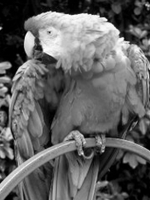

In [7]:
import requests
from PIL import Image

image_path = Path("sample_image.png")

if not image_path.exists():
    url = "https://upload.wikimedia.org/wikipedia/commons/f/fa/Grayscale_8bits_palette_sample_image.png"
    image = Image.open(requests.get(url, stream=True).raw)
    image.save(image_path)
else:
    image = Image.open(image_path)

image

In [8]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "https://upload.wikimedia.org/wikipedia/commons/f/fa/Grayscale_8bits_palette_sample_image.png"},
            {"type": "text", "text": "describe this image, please be careful to not miss any details."},
        ],
    }
]

inputs = processor.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt").to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=8192)
output_text = processor.decode(generated_ids[0][inputs["input_ids"].shape[1] :], skip_special_tokens=False)
print(output_text)

<think>Got it, let's analyze the image step by step. First, the main subject is a parrot, likely a large one like an Amazon or African Grey, given its size and features. The image is in black and white, so we need to focus on shapes, textures, and details. 

First, the parrot's posture: it's perched, maybe on a branch or a stand, with its body positioned. The feathers are detailed—there's a mix of smooth and textured areas, showing the plumage's texture. The parrot's head is turned, maybe looking at its own body or something nearby. The beak is visible, curved, typical of parrots. 

Then, the background: there's foliage, so it's probably in a natural or semi-natural setting, like a cage with plants. The background is slightly blurred, which brings focus to the parrot. 

Details like the claws gripping the perch (the curved metal or wooden stand), the feathers' patterns—some areas are smoother, others have more texture, indicating different feather types. The parrot's eye is visible, th

## Interactive demo
[back to top ⬆️](#Table-of-contents:)

In [ ]:
from gradio_helper import make_demo

demo = make_demo(model, processor)

try:
    demo.launch(debug=True, height=600)
except Exception:
    demo.launch(debug=True, share=True, height=600)
# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/